# 01 · Quickstart: your first Valuein query

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/01_quickstart.ipynb)

**What you will learn**

- How to connect with `ValueinClient` and check which plan and data snapshot you are reading.
- How to turn a ticker into a CIK, the stable company key every table joins on.
- How to discover tables and columns without downloading data.
- How to run SQL against SEC fundamentals and plot the result.
- How to call a ready-made SQL template.

**Plan required:** none. This notebook runs on the free sample tier (S&P 500 companies, last
five years) with no API key and no sign-up. If `VALUEIN_API_KEY` is set in your environment,
the same code reads your plan's data instead.

In [1]:
%pip install -q "valuein-sdk>=7.0.0" matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Connect

`ValueinClient()` looks for an API key in the `VALUEIN_API_KEY` environment variable (or a
`.env` file). With no key it uses the public sample dataset and prints a one-time notice saying
so. Nothing is downloaded yet: each table is fetched the first time a query needs it, then
cached on disk.

`as_of` is the point-in-time cutoff of the session. It defaults to "now"; notebook 02 shows how
to move it into the past.

In [2]:
from valuein_sdk import ValueinClient

client = ValueinClient()

print("plan     :", client.plan)
print("as_of    :", client.as_of.isoformat(timespec="seconds"))
print("snapshot :", client.manifest().get("snapshot"))


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


plan     : sample
as_of    : 2026-10-09T05:14:32+00:00
snapshot : snapshot_20261005


## 2. Tickers and CIKs

A ticker is a convenience: tickers get retired and later reused by unrelated companies. The SEC
Central Index Key (CIK) never changes, so every Valuein table is keyed on it (`cik` or
`entity_id`, zero-padded to 10 digits). `client.resolve()` shows what each identifier matched.
Every company-scoped method accepts either form.

In [3]:
client.resolve(["AAPL", "MSFT", 320193])

,identifier,cik,symbol,name,is_active,valid_from,valid_to,matched_by
0,AAPL,0000320193,AAPL,Apple Inc.,True,1994-01-26,NaT,ticker
1,MSFT,0000789019,MSFT,MICROSOFT CORP,True,1994-02-14,NaT,ticker
2,320193,0000320193,AAPL,Apple Inc.,True,1994-01-26,NaT,cik


## 3. What is in the data?

`get_schema()` answers from the manifest, so it costs no download. The tables you will use most:

| Table | One row per | Use it for |
|---|---|---|
| `references` | security (ticker listing) | the starting point for cross-company queries: `cik`, `symbol`, `name`, `sector`, `is_active` |
| `index_membership` | membership spell | who was in the S&P 500 on a given date (`effective_date` to `removal_date`) |
| `filing` | SEC filing | form type, filing date, `accepted_at`, links to sec.gov |
| `fact` | reported number | every standardized financial value, with the filing it came from |
| `ratio` | ratio value | pre-computed ratios (margins, returns, leverage, valuation multiples) |
| `stock_price` | month-end or period-end close | prices on the free tiers |
| `restatement_events` | changed fact | every number a later filing revised |

In [4]:
fact_columns = client.get_schema("fact")
print(len(fact_columns), "columns in fact, for example:")
for name in ["entity_id", "accession_id", "standard_concept", "period_end", "fiscal_period",
             "numeric_value", "unit", "accepted_at", "fact_id"]:
    print(f"  {name:<18} {fact_columns[name]}")

38 columns in fact, for example:
  entity_id          VARCHAR
  accession_id       VARCHAR
  standard_concept   VARCHAR
  period_end         DATE
  fiscal_period      VARCHAR
  numeric_value      DOUBLE
  unit               VARCHAR
  accepted_at        TIMESTAMPTZ
  fact_id            VARCHAR


## 4. Cross-company SQL: the S&P 500 by sector

`run_query()` runs read-only DuckDB SQL in your Python process. There is no `is_sp500` flag:
membership lives in `index_membership`, joined on `cik`. A spell with no `removal_date` is a
current member.

In [5]:
by_sector = client.run_query("""
    SELECT r.sector, count(DISTINCT r.cik) AS companies
    FROM "references" r
    JOIN index_membership im ON im.cik = r.cik
    WHERE im.index_name = 'SP500'
      AND im.removal_date IS NULL
    GROUP BY r.sector
    ORDER BY companies DESC
""")
by_sector

,sector,companies
0,Industrials,99
1,Financials,96
2,Information Technology,89
3,Health Care,62
4,Consumer Discretionary,38
5,Utilities,35
6,Consumer Staples,28
7,Materials,25
8,Energy,15
9,Communication Services,14


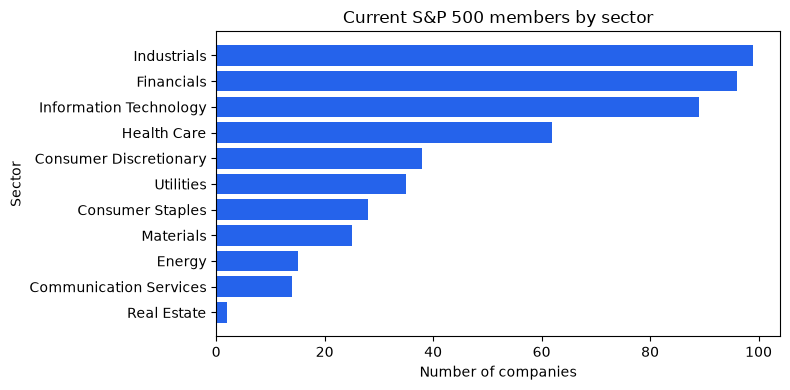

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(by_sector["sector"], by_sector["companies"], color="#2563eb")
ax.invert_yaxis()
ax.set_xlabel("Number of companies")
ax.set_ylabel("Sector")
ax.set_title("Current S&P 500 members by sector")
plt.tight_layout()
plt.show()

## 5. One company's fundamentals

A 10-K reports the current year and repeats prior years as comparatives, and a later filing can
revise an old number. So one fiscal year can appear in several rows of `fact`. Two rules give a
clean annual series:

1. Identify the period by `period_end` (and `fiscal_period = 'FY'` for annual values). Do not
   group by the filing's date: one filing carries several periods.
2. Keep one row per period: here the most recent vintage (`ORDER BY accepted_at DESC`). When
   several XBRL tags in one filing map to the same concept, `priority = 1` marks the one Valuein
   elected, so `priority DESC` breaks the tie.

`period_span_days` filters out the occasional quarterly value tagged inside an annual report.

In [7]:
cik = client.resolve("AAPL")["cik"].iloc[0]

annual = client.run_query(f"""
    SELECT period_end, standard_concept, numeric_value / 1e9 AS usd_bn, accession_id
    FROM fact
    WHERE entity_id = '{cik}'
      AND standard_concept IN ('TotalRevenue', 'NetIncome')
      AND fiscal_period = 'FY'
      AND period_span_days BETWEEN 350 AND 380
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY standard_concept, period_end ORDER BY accepted_at DESC, priority DESC
    ) = 1
    ORDER BY period_end, standard_concept
""")
wide = annual.pivot(index="period_end", columns="standard_concept", values="usd_bn")
wide.round(1)

standard_concept,NetIncome,TotalRevenue
period_end,,
2021-09-25,94.7,365.8
2022-09-24,99.8,394.3
2023-09-30,97.0,383.3
2024-09-28,93.7,391.0
2025-09-27,112.0,416.2


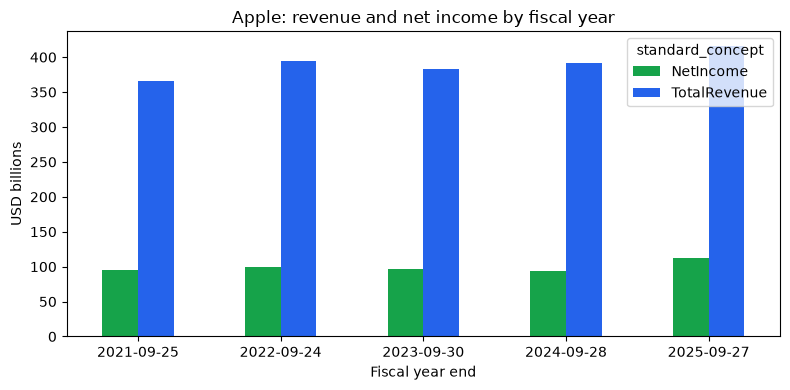

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
wide.plot.bar(ax=ax, color=["#16a34a", "#2563eb"])
ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in wide.index], rotation=0)
ax.set_xlabel("Fiscal year end")
ax.set_ylabel("USD billions")
ax.set_title("Apple: revenue and net income by fiscal year")
plt.tight_layout()
plt.show()

## 6. Ready-made SQL templates

The SDK ships parameterized SQL templates for common questions. Parameters are passed as
keyword arguments and validated before anything runs.

In [9]:
templates = client.list_templates()
print(len(templates), "templates, for example:", ", ".join(templates[:6]))

client.run_template("revenue_yoy_growth", ticker="AAPL")

57 templates, for example: 8k_event_frequency, 8k_material_event_signal, altman_z_score_inputs, as_filed_vs_latest_restatements, blockholders, capex_to_revenue


,period_end,fiscal_period,report_date,revenue,prev_year_revenue,yoy_growth
0,2025-09-27,FY,2025-09-27,4.161610e+11,3.910350e+11,0.064255
1,2024-09-28,FY,2025-09-27,3.910350e+11,3.832850e+11,0.020220
2,2023-09-30,FY,2025-09-27,3.832850e+11,3.943280e+11,-0.028005
3,2022-09-24,FY,2024-09-28,3.943280e+11,3.658170e+11,0.077938
4,2021-09-25,FY,2023-09-30,3.658170e+11,NaN,NaN


In [10]:
client.close()

## Next steps

- **[02 · Fundamentals as of a date](02_fundamentals_as_of_a_date.ipynb)**: see exactly what
  was known on a past date, and avoid the quarterly cash-flow trap.
- [`examples/README.md`](../README.md) lists the full learning path.
- Every `standard_concept` name is in [`docs/data_catalog.md`](../../docs/data_catalog.md).